# Experiment Analysis

**Philosophy:** The experiment ran — now what? Each section covers one step in the analysis pipeline, with explicit attention to the interview pitfalls that trip people up most often.

---

## Decision Table

| If you need to... | Go to |
| :--- | :--- |
| Know what order to run the analysis steps | §1 — Analysis Pipeline |
| Compute ATE, p-value, CI — incl. skewed & ratio metrics | §2 — Statistical Testing |
| Reduce variance to get results faster | §3 — Variance Reduction |
| Test multiple metrics/segments, or peek safely | §4 — Multiple Testing & Peeking |
| Answer "would you do this Bayesian?" | §5 — Bayesian A/B & Bandits |
| Diagnose why results look wrong | §6 — Pitfalls & Diagnostics |
| Turn results into a ship/no-ship decision | §7 — Decisions & Communication |

In [1]:
# ── Shared dark plot theme ───────────────────────────────────────────────────
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt

BG, PANEL, GRID = '#0b0e14', '#13171f', '#1e2433'
TXT, MUT = '#d4dbe8', '#6b7a99'
CYAN, AMBER, GREEN, RED, PURPLE = '#4fc4cf', '#f0c674', '#7ec98a', '#f76f6f', '#b294bb'

def dark_fig(nrows=1, ncols=1, figsize=(12, 4)):
    fig, axes = plt.subplots(nrows, ncols, figsize=figsize)
    fig.patch.set_facecolor(BG)
    for ax in np.ravel(axes):
        ax.set_facecolor(PANEL)
        ax.tick_params(colors=MUT)
        ax.spines[:].set_color(GRID)
        ax.grid(True, alpha=0.2, color=GRID)
    return fig, axes

def style_labels(ax, xlabel=None, ylabel=None, title=None):
    if xlabel: ax.set_xlabel(xlabel, color=TXT)
    if ylabel: ax.set_ylabel(ylabel, color=TXT)
    if title:  ax.set_title(title, color=TXT, fontsize=11)

def dark_legend(ax, **kw):
    ax.legend(labelcolor=TXT, facecolor=PANEL, edgecolor=GRID, fontsize=9, **kw)

---
## §1 — The Analysis Pipeline

Always follow this order. Steps 1–3 are validity checks — if any fail, stop before looking at the primary metric.

```
Step 1  SRM check                Did the groups receive the expected traffic split?
         └── If fails → stop. Results are invalid.

Step 2  Covariate balance        Are pre-experiment characteristics equal across groups?
         └── If fails → stop. Randomization is broken.

Step 3  Data quality             Outliers? Missing data? Logging gaps?
         └── Winsorize extreme values before computing means (§2).

Step 4  Primary metric           Compute ATE, 95% CI, p-value.
         └── Report effect size AND practical significance, not just p-value.
         └── Ratio metric with analysis unit ≠ randomization unit? Delta method (§2).

Step 5  Guardrail metrics        Did any guardrail degrade?
         └── If yes → do not ship, even if primary metric is positive.

Step 6  Segment analysis         Does the effect differ by platform, country, tenure?
         └── Apply multiple testing correction. Treat as exploratory.

Step 7  Recommend                Ship / no-ship / iterate — with justification (§7).
```

---
## §2 — Statistical Testing

### 2.1 — The standard tests

── Continuous metric (t-test) ──
Control mean:    12.028
Treatment mean:  12.551
ATE:             +0.523  (4.35% relative lift)
95% CI:          [0.326, 0.719]
p-value:         0.0000
Cohen's d:       0.104  (small)

── Proportion metric (z-test) ──
Control rate:    9.800%
Treatment rate:  10.500%
Absolute lift:   +0.0070  (7.14% relative)
95% CI:          [-0.0014, 0.0154]
z = 1.639,  p = 0.1012

── Non-parametric (Mann-Whitney U) ──
U = 13202335,  p = 0.0000


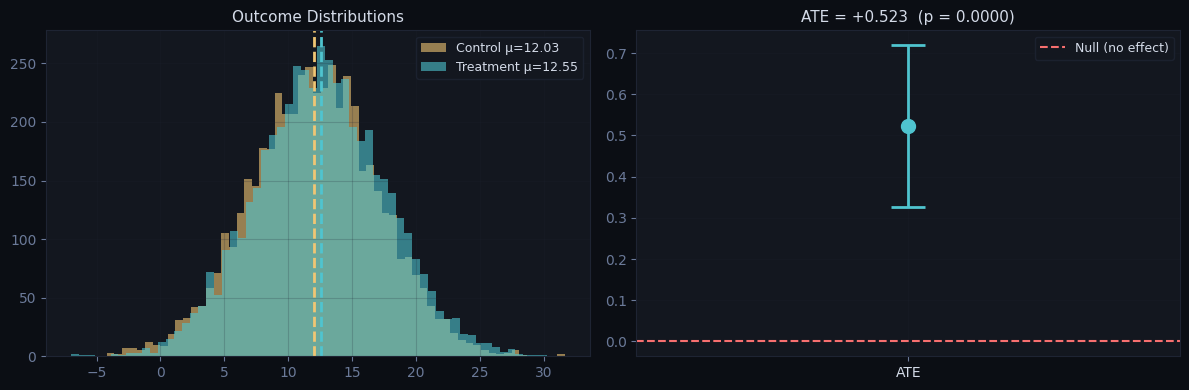

In [2]:
np.random.seed(42)

# ── Test A: Continuous metric — two-sample t-test ────────────────────────────
# Use when: metric is continuous (session length, revenue per user)
n = 5_000
ctrl = np.random.normal(loc=12.0, scale=5.0, size=n)   # control: mean=12
trt  = np.random.normal(loc=12.6, scale=5.0, size=n)   # treatment: mean=12.6

ate   = trt.mean() - ctrl.mean()
se    = np.sqrt(ctrl.std()**2/n + trt.std()**2/n)
ci_lo, ci_hi = ate - 1.96 * se, ate + 1.96 * se
t_stat, p_val = stats.ttest_ind(trt, ctrl)
cohens_d = ate / np.sqrt((ctrl.std()**2 + trt.std()**2) / 2)

print("── Continuous metric (t-test) ──")
print(f"Control mean:    {ctrl.mean():.3f}")
print(f"Treatment mean:  {trt.mean():.3f}")
print(f"ATE:             {ate:+.3f}  ({ate/ctrl.mean():.2%} relative lift)")
print(f"95% CI:          [{ci_lo:.3f}, {ci_hi:.3f}]")
print(f"p-value:         {p_val:.4f}")
print(f"Cohen's d:       {cohens_d:.3f}  "
      f"{'(small)' if abs(cohens_d)<0.3 else '(medium)' if abs(cohens_d)<0.5 else '(large)'}")
print()

# ── Test B: Proportion metric — z-test for proportions ───────────────────────
n_c, conv_c = 10_000, 980     # control: 9.8% conversion
n_t, conv_t = 10_000, 1_050   # treatment: 10.5% conversion

p_c, p_t = conv_c / n_c, conv_t / n_t
p_pool = (conv_c + conv_t) / (n_c + n_t)
se_prop = np.sqrt(p_pool * (1-p_pool) * (1/n_c + 1/n_t))
z_stat  = (p_t - p_c) / se_prop
p_val_prop = 2 * (1 - stats.norm.cdf(abs(z_stat)))
ci_prop = (p_t - p_c) + np.array([-1, 1]) * 1.96 * np.sqrt(p_c*(1-p_c)/n_c + p_t*(1-p_t)/n_t)

print("── Proportion metric (z-test) ──")
print(f"Control rate:    {p_c:.3%}")
print(f"Treatment rate:  {p_t:.3%}")
print(f"Absolute lift:   {p_t-p_c:+.4f}  ({(p_t-p_c)/p_c:.2%} relative)")
print(f"95% CI:          [{ci_prop[0]:.4f}, {ci_prop[1]:.4f}]")
print(f"z = {z_stat:.3f},  p = {p_val_prop:.4f}")
print()

# ── Non-parametric — Mann-Whitney U ──────────────────────────────────────────
# Use when: heavily skewed, small sample, or ordinal
u_stat, p_mw = stats.mannwhitneyu(trt, ctrl, alternative='two-sided')
print(f"── Non-parametric (Mann-Whitney U) ──")
print(f"U = {u_stat:.0f},  p = {p_mw:.4f}")

# ── Visualization ────────────────────────────────────────────────────────────
fig, axes = dark_fig(1, 2)
axes[0].hist(ctrl, bins=60, alpha=0.6, color=AMBER, label=f'Control μ={ctrl.mean():.2f}')
axes[0].hist(trt,  bins=60, alpha=0.6, color=CYAN,  label=f'Treatment μ={trt.mean():.2f}')
axes[0].axvline(ctrl.mean(), color=AMBER, lw=2, ls='--')
axes[0].axvline(trt.mean(),  color=CYAN,  lw=2, ls='--')
style_labels(axes[0], title='Outcome Distributions')
dark_legend(axes[0])

axes[1].errorbar([1], [ate], yerr=[[ate-ci_lo], [ci_hi-ate]], fmt='o', color=CYAN,
                 capsize=12, capthick=2, markersize=10, lw=2)
axes[1].axhline(0, color=RED, lw=1.5, ls='--', label='Null (no effect)')
axes[1].set_xlim(0, 2); axes[1].set_xticks([1])
axes[1].set_xticklabels(['ATE'], color=TXT)
style_labels(axes[1], title=f'ATE = {ate:+.3f}  (p = {p_val:.4f})')
dark_legend(axes[1])
plt.tight_layout(); plt.show()

**Statistical vs practical significance:** with large n, even tiny effects become statistically significant — always report effect size (Cohen's d: 0.2 small / 0.5 medium / 0.8 large) and CI alongside the p-value.

**Which test to use:**

| Metric type | Test | Notes |
| :--- | :--- | :--- |
| Continuous, approx. normal | Two-sample t-test | — |
| Binary / proportion | Z-test for proportions | — |
| Heavily skewed, small n | Mann-Whitney U | Revenue, session counts |
| Any metric, unknown distribution | Bootstrap (2.2) | Universal but slower |
| Ratio metric (CTR), randomized by user | Delta method (2.3) | Naive SE is badly wrong |

### 2.2 — Skewed metrics: Winsorization and the bootstrap

Revenue-type metrics are heavy-tailed: a single whale can swing the ATE. Two standard tools:

- **Winsorization** — cap values at a high percentile (P99 or P99.9) computed on the *pooled* data. Stabilizes the mean and slashes variance. Caveat to state in an interview: it **changes the estimand** — you now measure the effect on Winsorized revenue, which deliberately mutes effects on whales. If the treatment targets big spenders, don't cap away your effect.
- **Bootstrap** — resample units with replacement, recompute the statistic, take percentiles. Makes no distributional assumption; the right tool when the metric is weird or the statistic isn't a mean (medians, percentiles, ratios).

Raw means:        ctrl $5.43   trt $17.74   'lift' +226.9%  ← 3 whales fake a huge lift
Winsorized (P99): ctrl $5.12   trt $5.46   lift +6.7%  ← close to the true +4%
SD drops 10.3 → 7.1 — variance reduction for free



Bootstrap 95% CI for Winsorized ATE: [0.139, 0.554]   (excludes 0 → significant)


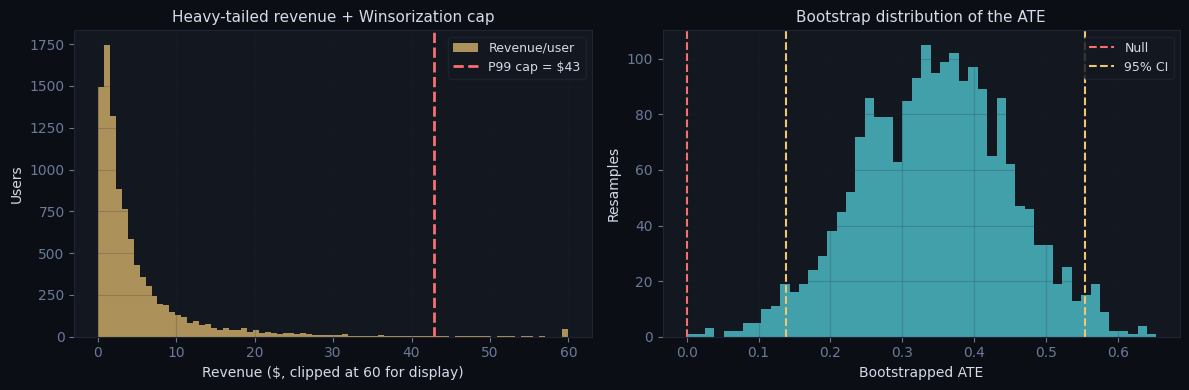

In [3]:
np.random.seed(3)
n = 10_000
rev_ctrl = np.random.lognormal(1.0, 1.2, n)
rev_trt  = np.random.lognormal(1.0, 1.2, n) * 1.04            # +4% true lift
rev_trt[np.random.choice(n, 3, replace=False)] += 40_000      # 3 whales land in treatment

print(f"Raw means:        ctrl ${rev_ctrl.mean():.2f}   trt ${rev_trt.mean():.2f}   "
      f"'lift' {(rev_trt.mean()/rev_ctrl.mean()-1):+.1%}  ← 3 whales fake a huge lift")

# ── Winsorize at P99 of the POOLED distribution ─────────────────────────────
cap = np.quantile(np.concatenate([rev_ctrl, rev_trt]), 0.99)
w_ctrl, w_trt = np.minimum(rev_ctrl, cap), np.minimum(rev_trt, cap)
print(f"Winsorized (P99): ctrl ${w_ctrl.mean():.2f}   trt ${w_trt.mean():.2f}   "
      f"lift {(w_trt.mean()/w_ctrl.mean()-1):+.1%}  ← close to the true +4%")
print(f"SD drops {rev_ctrl.std():.1f} → {w_ctrl.std():.1f} — variance reduction for free")

# ── Bootstrap CI for the (Winsorized) ATE — percentile method ────────────────
def bootstrap_ci(c, t, stat=np.mean, n_boot=2000, alpha=0.05, seed=0):
    rng  = np.random.default_rng(seed)
    diffs = np.array([stat(rng.choice(t, len(t))) - stat(rng.choice(c, len(c)))
                      for _ in range(n_boot)])
    return diffs, np.quantile(diffs, [alpha/2, 1 - alpha/2])

diffs, (b_lo, b_hi) = bootstrap_ci(w_ctrl, w_trt)
print(f"\nBootstrap 95% CI for Winsorized ATE: [{b_lo:.3f}, {b_hi:.3f}]"
      f"   (excludes 0 → significant)" if b_lo > 0 else "")

fig, axes = dark_fig(1, 2)
bins = np.linspace(0, 60, 80)
axes[0].hist(np.clip(rev_ctrl, 0, 60), bins=bins, alpha=0.7, color=AMBER, label='Revenue/user')
axes[0].axvline(cap, color=RED, lw=2, ls='--', label=f'P99 cap = ${cap:.0f}')
style_labels(axes[0], 'Revenue ($, clipped at 60 for display)', 'Users',
             'Heavy-tailed revenue + Winsorization cap')
dark_legend(axes[0])

axes[1].hist(diffs, bins=50, color=CYAN, alpha=0.8)
axes[1].axvline(0, color=RED, lw=1.5, ls='--', label='Null')
axes[1].axvline(b_lo, color=AMBER, lw=1.5, ls='--', label='95% CI')
axes[1].axvline(b_hi, color=AMBER, lw=1.5, ls='--')
style_labels(axes[1], 'Bootstrapped ATE', 'Resamples', 'Bootstrap distribution of the ATE')
dark_legend(axes[1])
plt.tight_layout(); plt.show()

### 2.3 — Ratio metrics: the delta method

CTR = total clicks / total views. You randomized **users**, but the metric's units are **views** — views from the same user are correlated, so treating each view as an independent Bernoulli underestimates the SE (same disease as Design §3's simulation). Three valid fixes; the naive one is the interview trap.

```
Naive (WRONG):    SE = √(p(1−p)/N_views)              treats views as independent
Delta method:     Var(X̄/Ȳ) ≈ (1/n)·(σ²x/μ²y − 2μxσxy/μ³y + μ²xσ²y/μ⁴y)
                  where X = clicks per USER, Y = views per USER, n = #users
Bootstrap users:  resample users (not views) — the assumption-free check
```

CTR = 0.1016
SE naive (views independent): 0.00151
SE delta method (per user):   0.00167
SE bootstrap over users:      0.00166

Naive SE is 1.1× too small → CIs too narrow → false positives.
Delta method ≈ user-bootstrap: both respect the randomization unit.


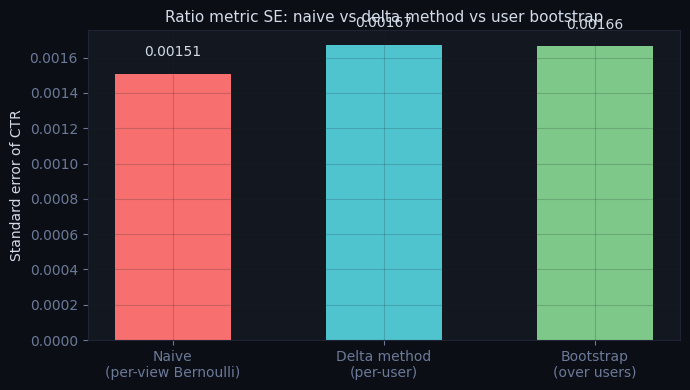

In [4]:
np.random.seed(11)
n_users = 8_000

def make_group(p_mean):
    views  = 1 + np.random.poisson(4, n_users)
    p_user = np.random.beta(p_mean * 20, (1 - p_mean) * 20, n_users)  # overdispersion
    clicks = np.random.binomial(views, p_user)
    return clicks.astype(float), views.astype(float)

def delta_se(clicks, views):
    n = len(clicks)
    mx, my = clicks.mean(), views.mean()
    vx, vy = clicks.var(ddof=1), views.var(ddof=1)
    cxy = np.cov(clicks, views, ddof=1)[0, 1]
    return np.sqrt((vx/my**2 - 2*mx*cxy/my**3 + mx**2*vy/my**4) / n)

c_clicks, c_views = make_group(0.10)
ctr = c_clicks.sum() / c_views.sum()

se_naive = np.sqrt(ctr * (1 - ctr) / c_views.sum())
se_delta = delta_se(c_clicks, c_views)

rng = np.random.default_rng(0)
boot = []
for _ in range(2000):
    idx = rng.integers(0, n_users, n_users)            # resample USERS
    boot.append(c_clicks[idx].sum() / c_views[idx].sum())
se_boot = np.std(boot)

print(f"CTR = {ctr:.4f}")
print(f"SE naive (views independent): {se_naive:.5f}")
print(f"SE delta method (per user):   {se_delta:.5f}")
print(f"SE bootstrap over users:      {se_boot:.5f}")
print(f"\nNaive SE is {se_delta/se_naive:.1f}× too small → CIs too narrow → false positives.")
print("Delta method ≈ user-bootstrap: both respect the randomization unit.")

fig, ax = dark_fig(figsize=(7, 4))
bars = ax.bar(['Naive\n(per-view Bernoulli)', 'Delta method\n(per-user)', 'Bootstrap\n(over users)'],
              [se_naive, se_delta, se_boot], color=[RED, CYAN, GREEN], width=0.55)
for b, v in zip(bars, [se_naive, se_delta, se_boot]):
    ax.text(b.get_x() + b.get_width()/2, v + 1e-4, f'{v:.5f}', ha='center', color=TXT)
style_labels(ax, ylabel='Standard error of CTR',
             title='Ratio metric SE: naive vs delta method vs user bootstrap')
plt.tight_layout(); plt.show()

**Common mistakes:**
- Reporting only p-value without effect size — a p=0.001 with Cohen's d=0.02 is statistically significant but practically useless
- Using a one-sided test to get a lower p-value — only valid if you pre-specified the direction; post-hoc it's p-hacking
- Ignoring outliers before computing means — one user with $10M revenue can swing the ATE; Winsorize, but state the estimand change
- Computing a per-view/per-session SE for a user-randomized ratio metric — use the delta method or bootstrap users
- Winsorizing each group at its *own* percentile — compute the cap on pooled data, or you bias the comparison

---
## §3 — Variance Reduction (CUPED & friends)

CUPED (Controlled-experiment Using Pre-Experiment Data) reduces outcome variance by removing the component explainable by a pre-experiment covariate. Same statistical power with a smaller sample — or faster experiments at the same power.

Corr(Y, X_pre) = 0.762  →  variance reduction ≈ 58.1%
Std(Y_ctrl):  3.128 → 2.021 after CUPED
ATE raw:   0.5409
ATE CUPED: 0.5409   ← same estimate, lower variance
p raw: 0.0000   p CUPED: 0.000000

Power-planning tie-back (Design §4): n_needed × (1 − ρ²) = 0.42 × original


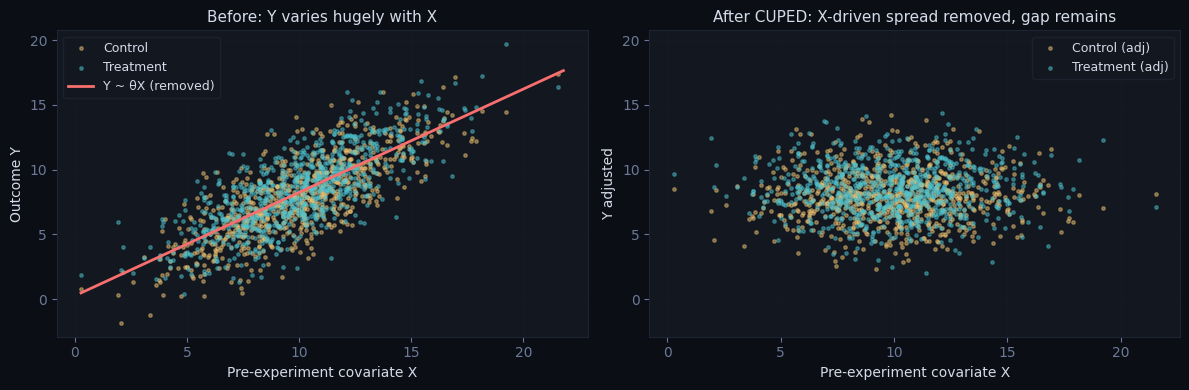

In [5]:
# ── CUPED: the idea ──────────────────────────────────────────────────────────
# Y_adjusted = Y − θ·(X − E[X]),  θ = Cov(Y,X)/Var(X)   (pooled across groups)
# Same mean, lower variance. Variance reduction factor ≈ 1 − Corr(Y,X)²

np.random.seed(42)
n = 5_000
X_pre  = np.random.normal(10, 3, n)                     # pre-experiment revenue
Y_ctrl = 0.8 * X_pre + np.random.normal(0, 2, n)
Y_trt  = 0.8 * X_pre + np.random.normal(0, 2, n) + 0.5  # true effect +0.5

# θ estimated on POOLED data (estimating per-group is also common; pooled is safest)
Y_all, X_all = np.concatenate([Y_ctrl, Y_trt]), np.concatenate([X_pre, X_pre])
theta = np.cov(Y_all, X_all)[0, 1] / np.var(X_all)
adj   = lambda Y, X: Y - theta * (X - X_all.mean())
Yc_adj, Yt_adj = adj(Y_ctrl, X_pre), adj(Y_trt, X_pre)

corr = np.corrcoef(Y_all, X_all)[0, 1]
print(f"Corr(Y, X_pre) = {corr:.3f}  →  variance reduction ≈ {corr**2:.1%}")
print(f"Std(Y_ctrl):  {Y_ctrl.std():.3f} → {Yc_adj.std():.3f} after CUPED")
print(f"ATE raw:   {Y_trt.mean()-Y_ctrl.mean():.4f}")
print(f"ATE CUPED: {Yt_adj.mean()-Yc_adj.mean():.4f}   ← same estimate, lower variance")
_, p_raw   = stats.ttest_ind(Y_trt,  Y_ctrl)
_, p_cuped = stats.ttest_ind(Yt_adj, Yc_adj)
print(f"p raw: {p_raw:.4f}   p CUPED: {p_cuped:.6f}")
print(f"\nPower-planning tie-back (Design §4): n_needed × (1 − ρ²) "
      f"= {1-corr**2:.2f} × original")

# ── Visualize: what "removing explainable variance" means ────────────────────
fig, axes = dark_fig(1, 2)
axes[0].scatter(X_pre[:800], Y_ctrl[:800], s=6, alpha=0.45, color=AMBER, label='Control')
axes[0].scatter(X_pre[:800], Y_trt[:800],  s=6, alpha=0.45, color=CYAN,  label='Treatment')
xs = np.linspace(X_pre.min(), X_pre.max(), 10)
axes[0].plot(xs, theta * (xs - X_all.mean()) + Y_all.mean(), color=RED, lw=2,
             label='Y ~ θX (removed)')
style_labels(axes[0], 'Pre-experiment covariate X', 'Outcome Y',
             'Before: Y varies hugely with X')
dark_legend(axes[0])

axes[1].scatter(X_pre[:800], Yc_adj[:800], s=6, alpha=0.45, color=AMBER, label='Control (adj)')
axes[1].scatter(X_pre[:800], Yt_adj[:800], s=6, alpha=0.45, color=CYAN,  label='Treatment (adj)')
axes[1].set_ylim(axes[0].get_ylim())
style_labels(axes[1], 'Pre-experiment covariate X', 'Y adjusted',
             'After CUPED: X-driven spread removed, gap remains')
dark_legend(axes[1])
plt.tight_layout(); plt.show()

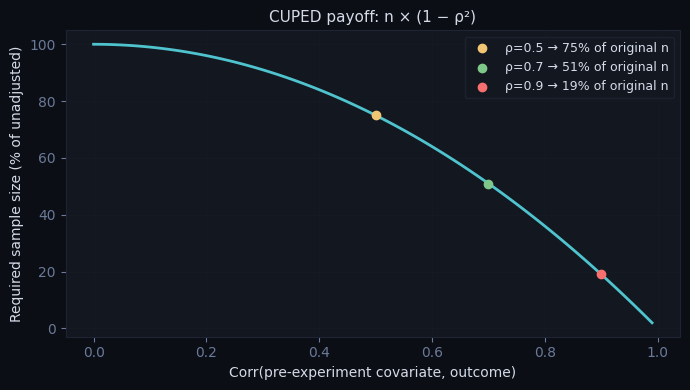

ATE raw: 0.418   ATE post-stratified: 0.421 (lower-variance estimator)


In [6]:
# ── How much CUPED helps, as a function of correlation ───────────────────────
rho = np.linspace(0, 0.99, 100)
fig, ax = dark_fig(figsize=(7, 4))
ax.plot(rho, (1 - rho**2) * 100, color=CYAN, lw=2)
for r, c in [(0.5, AMBER), (0.7, GREEN), (0.9, RED)]:
    ax.scatter([r], [(1 - r**2) * 100], color=c, zorder=5,
               label=f'ρ={r} → {1-r**2:.0%} of original n')
style_labels(ax, 'Corr(pre-experiment covariate, outcome)',
             'Required sample size (% of unadjusted)',
             'CUPED payoff: n × (1 − ρ²)')
dark_legend(ax)
plt.tight_layout(); plt.show()

# ── Post-stratification: the no-covariate-history alternative ────────────────
# Reweight strata means to the overall strata shares — removes between-stratum
# variance. Works with categorical covariates (platform, country) even when a
# pre-period metric doesn't exist (e.g. brand-new users).
np.random.seed(5)
df = pd.DataFrame({
    'g': np.repeat(['ctrl', 'trt'], 4000),
    'stratum': np.random.choice(['iOS', 'Android'], 8000, p=[0.4, 0.6]),
})
base = df['stratum'].map({'iOS': 14.0, 'Android': 10.0})
df['y'] = base + np.random.normal(0, 3, 8000) + 0.4 * (df['g'] == 'trt')

shares = df['stratum'].value_counts(normalize=True)
strat_means = df.groupby(['g', 'stratum'])['y'].mean().unstack()
ate_ps = ((strat_means.loc['trt'] - strat_means.loc['ctrl']) * shares).sum()
ate_raw = df[df.g=='trt'].y.mean() - df[df.g=='ctrl'].y.mean()
print(f"ATE raw: {ate_raw:.3f}   ATE post-stratified: {ate_ps:.3f} (lower-variance estimator)")

**Key points:**
- CUPED does not change the ATE estimate — it only reduces variance
- `X` must be from **before** the experiment — post-exposure covariates can be affected by treatment → biased adjustment
- Variance reduction factor = `1 − Corr(Y, X)²`; the best X is usually *the same metric, pre-period*
- **Post-stratification / regression adjustment** = CUPED's categorical cousins; **CUPAC** = use an ML model's prediction of Y (trained on pre-experiment data) as the covariate — same math, higher ρ
- Plan sample size assuming the adjustment (Design §4.4)

**Common mistakes:**
- Using a covariate measured during the experiment as X — leakage, biased adjustment
- Applying CUPED when ρ is low — minimal benefit, added complexity
- New users have no pre-period data — either post-stratify on attributes or accept partial coverage (apply CUPED only where X exists)

---
## §4 — Multiple Testing & Peeking

Every additional test — another metric, another segment, **or another look at the same metric** — increases the chance of a false positive.

### 4.1 — Multiple metrics & segments

In [7]:
from statsmodels.stats.multitest import multipletests

# Simulate 20 metrics, all null — how many false positives?
np.random.seed(42)
n_tests = 20
p_values_null = np.array([stats.ttest_ind(np.random.normal(0, 1, 500),
                                          np.random.normal(0, 1, 500))[1]
                          for _ in range(n_tests)])

print(f"False positives (uncorrected, α=0.05): {(p_values_null < 0.05).sum()} of {n_tests}")

# Bonferroni — most conservative, controls family-wise error rate
alpha_bonf = 0.05 / n_tests
print(f"After Bonferroni (α={alpha_bonf:.4f}):         "
      f"{(p_values_null < alpha_bonf).sum()} false positives")

# Benjamini-Hochberg — controls false discovery rate, preferred for DS experiments
reject_bh, p_adj_bh, _, _ = multipletests(p_values_null, alpha=0.05, method='fdr_bh')
print(f"After Benjamini-Hochberg FDR:              {reject_bh.sum()} false positives")

print()
print("Pre-registration tiers:")
print("  Primary metric (1):   no correction — this is THE decision metric")
print("  Guardrail metrics:    no correction — binary pass/fail, not hypothesis tests")
print("  Secondary metrics:    BH-FDR — exploratory, report as directional")
print("  Segment breakdowns:   BH-FDR — hypothesis-generating only")

False positives (uncorrected, α=0.05): 0 of 20
After Bonferroni (α=0.0025):         0 false positives
After Benjamini-Hochberg FDR:              0 false positives

Pre-registration tiers:
  Primary metric (1):   no correction — this is THE decision metric
  Guardrail metrics:    no correction — binary pass/fail, not hypothesis tests
  Secondary metrics:    BH-FDR — exploratory, report as directional
  Segment breakdowns:   BH-FDR — hypothesis-generating only


**Bonferroni vs BH-FDR:**

| | Bonferroni | Benjamini-Hochberg FDR |
| :--- | :--- | :--- |
| Controls | Family-wise error rate (FWER) | False discovery rate (FDR) |
| Conservatism | Very conservative | Less conservative |
| Power | Lower | Higher |
| Use when | Any false positive is costly | Some false positives acceptable |
| Common use | Clinical trials, safety tests | DS experiments, segment analysis |

### 4.2 — Peeking: why "stop when significant" breaks everything

Recomputing the p-value daily and stopping at the first p < 0.05 is **implicit multiple testing on the same data**. The industry-standard picture is the **p-value trajectory plot** — the p-value over time on cumulative data:

- Under the **null**, the trajectory is a random walk that will *transiently* dip below 0.05 by chance. A daily peeker catches the dip and ships a false positive.
- Under a **true effect**, the trajectory declines and *stays* down (the test statistic grows like √n).

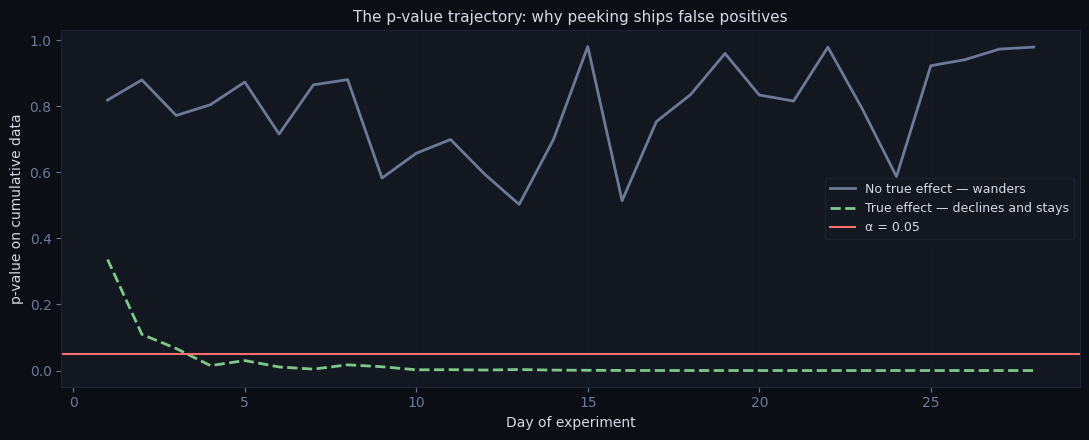

In [8]:
# ── The p-value trajectory plot ──────────────────────────────────────────────
np.random.seed(8)
days, n_day = 28, 200

def trajectory(effect):
    c = np.random.normal(0, 1, days * n_day)
    t = np.random.normal(effect, 1, days * n_day)
    return np.array([stats.ttest_ind(t[:d*n_day], c[:d*n_day])[1]
                     for d in range(1, days + 1)])

p_null = trajectory(0.0)        # no true effect
p_true = trajectory(0.06)       # small true effect

fig, ax = dark_fig(figsize=(11, 4.5))
x = np.arange(1, days + 1)
ax.plot(x, p_null, color=MUT,  lw=2, label='No true effect — wanders')
ax.plot(x, p_true, color=GREEN, lw=2, ls='--', label='True effect — declines and stays')
ax.axhline(0.05, color=RED, lw=1.5, label='α = 0.05')
dip = np.where(p_null < 0.05)[0]
if len(dip):
    ax.scatter(x[dip], p_null[dip], color=RED, zorder=5, s=45,
               label='Peeker stops here → false positive')
style_labels(ax, 'Day of experiment', 'p-value on cumulative data',
             'The p-value trajectory: why peeking ships false positives')
dark_legend(ax)
plt.tight_layout(); plt.show()

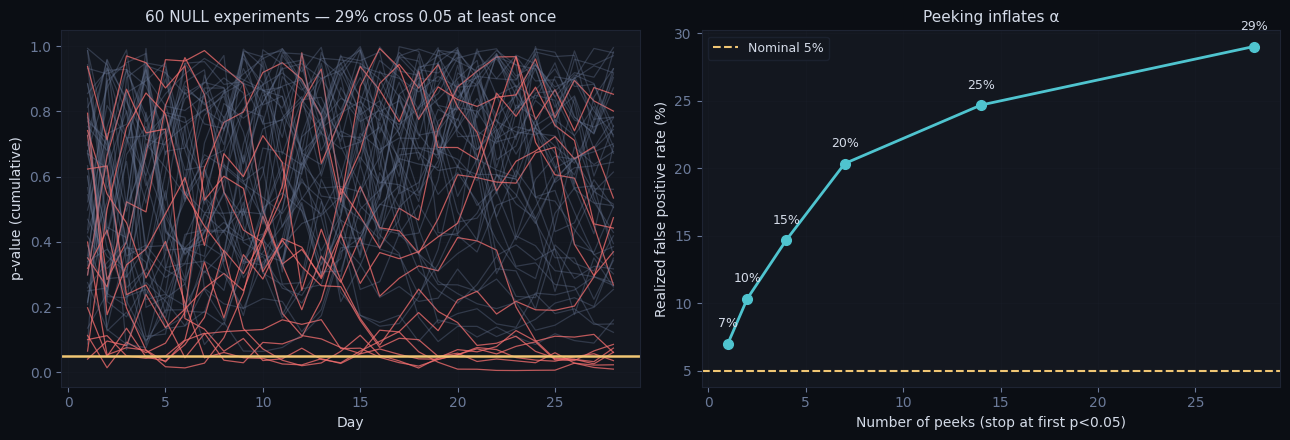

In [9]:
# ── How bad is it? Spaghetti plot + realized FPR vs number of peeks ─────────
np.random.seed(0)
n_sims, days, n_day = 300, 28, 150

# Vectorized daily z-stats under the NULL via cumulative sums
def daily_z(n_sims, days, n_day):
    c  = np.random.normal(0, 1, (n_sims, days * n_day))
    t  = np.random.normal(0, 1, (n_sims, days * n_day))
    idx = np.arange(1, days + 1) * n_day
    cs_c,  cs_t  = np.cumsum(c, 1)[:, idx-1],    np.cumsum(t, 1)[:, idx-1]
    cs_c2, cs_t2 = np.cumsum(c**2, 1)[:, idx-1], np.cumsum(t**2, 1)[:, idx-1]
    ns = idx[None, :]
    mc, mt = cs_c / ns, cs_t / ns
    vc, vt = cs_c2/ns - mc**2, cs_t2/ns - mt**2
    return (mt - mc) / np.sqrt(vc/ns + vt/ns)

z = daily_z(n_sims, days, n_day)
pvals = 2 * (1 - stats.norm.cdf(np.abs(z)))                  # (n_sims, days)

ever_crossed = (pvals < 0.05).any(axis=1).mean()

fig, axes = dark_fig(1, 2, figsize=(13, 4.5))
x = np.arange(1, days + 1)
for i in range(60):
    crossed = (pvals[i] < 0.05).any()
    axes[0].plot(x, pvals[i], lw=0.9, alpha=0.75 if crossed else 0.35,
                 color=RED if crossed else MUT)
axes[0].axhline(0.05, color=AMBER, lw=1.8)
style_labels(axes[0], 'Day', 'p-value (cumulative)',
             f'60 NULL experiments — {ever_crossed:.0%} cross 0.05 at least once')

# FPR if you stop at first significant peek, for K equally spaced peeks
peek_counts = [1, 2, 4, 7, 14, 28]
fprs = []
for K in peek_counts:
    looks = np.linspace(days/K, days, K).round().astype(int) - 1
    fprs.append((pvals[:, looks] < 0.05).any(axis=1).mean())
axes[1].plot(peek_counts, np.array(fprs) * 100, 'o-', color=CYAN, lw=2, markersize=7)
axes[1].axhline(5, color=AMBER, ls='--', lw=1.5, label='Nominal 5%')
for k, f in zip(peek_counts, fprs):
    axes[1].annotate(f'{f:.0%}', (k, f*100 + 1.2), color=TXT, ha='center', fontsize=9)
style_labels(axes[1], 'Number of peeks (stop at first p<0.05)',
             'Realized false positive rate (%)', 'Peeking inflates α')
dark_legend(axes[1])
plt.tight_layout(); plt.show()

### 4.3 — Peeking *legally*: sequential testing

If the business genuinely needs early looks, build them into the design:

- **Group sequential / alpha spending** (O'Brien–Fleming, Pocock): pre-specify K looks; each look gets a stricter threshold so the *total* α stays 0.05. OBF is near-impossible to cross early and ≈ 1.96 at the end — you give up almost nothing for the option to stop early on a huge effect.
- **Always-valid inference** (mSPRT, e-values): p-values/CIs valid at *every* point in time under continuous monitoring — what Optimizely-style "stats engines" implement. Costs wider CIs than a fixed-horizon test.

Rule: fixed horizon when you can wait; OBF when you want a few interim looks (esp. for harm/futility stopping); always-valid when stakeholders will watch the dashboard daily no matter what you say.

Look (info fraction) | OBF z-boundary | ≈ p-threshold | Pocock z
   20%               |     4.38      |    0.0000    |  2.41
   40%               |     3.10      |    0.0019    |  2.41
   60%               |     2.53      |    0.0114    |  2.41
   80%               |     2.19      |    0.0284    |  2.41
   100%               |     1.96      |    0.0500    |  2.41


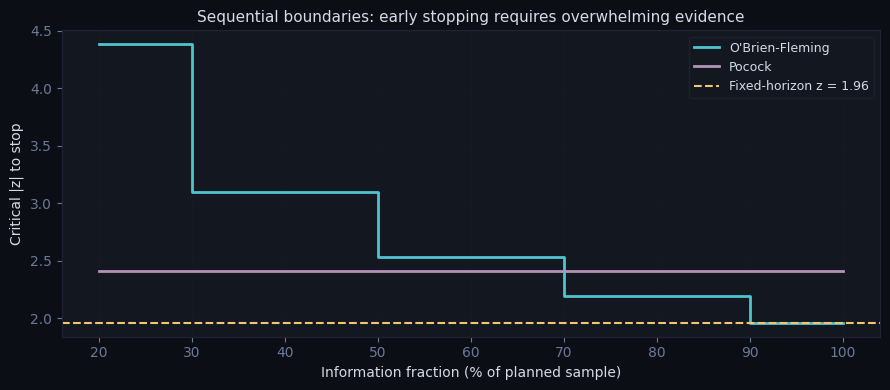


(Exact boundaries come from the joint distribution of the z-process —
 use a library in production; this marginal approximation is for intuition.)


In [10]:
# ── O'Brien-Fleming-style boundaries (classic approximation) ────────────────
# At information fraction t_k, marginal critical value z_k = z_{α/2} / √t_k
K = 5
t_k = np.arange(1, K + 1) / K
z_fixed = stats.norm.ppf(0.975)
obf     = z_fixed / np.sqrt(t_k)
pocock  = np.full(K, 2.413)                       # Pocock constant for K=5, α=0.05

print("Look (info fraction) | OBF z-boundary | ≈ p-threshold | Pocock z")
for t, zo, zp in zip(t_k, obf, pocock):
    print(f"   {t:.0%}               |     {zo:.2f}      |    {2*(1-stats.norm.cdf(zo)):.4f}    |  {zp:.2f}")

fig, ax = dark_fig(figsize=(9, 4))
ax.step(t_k * 100, obf,    where='mid', color=CYAN,  lw=2, label="O'Brien-Fleming")
ax.step(t_k * 100, pocock, where='mid', color=PURPLE, lw=2, label='Pocock')
ax.axhline(z_fixed, color=AMBER, ls='--', lw=1.5, label='Fixed-horizon z = 1.96')
style_labels(ax, 'Information fraction (% of planned sample)', 'Critical |z| to stop',
             'Sequential boundaries: early stopping requires overwhelming evidence')
dark_legend(ax)
plt.tight_layout(); plt.show()
print("\n(Exact boundaries come from the joint distribution of the z-process —")
print(" use a library in production; this marginal approximation is for intuition.)")

**Common mistakes:**
- Testing many segments post-hoc and reporting the significant ones without correction — p-hacking, even if unintentional
- Applying Bonferroni to guardrail metrics — guardrails are pass/fail checks, not hypothesis tests
- Treating a significant segment result as confirmatory — always exploratory, needs a follow-up experiment
- Computing fixed-horizon p-values daily on a dashboard and acting on them — either commit to the horizon or switch to sequential/always-valid methods
- Using sequential boundaries that weren't pre-specified — choosing OBF vs Pocock *after* seeing data is itself p-hacking

---
## §5 — Bayesian A/B Testing & Bandits

The standard interview question: *"would you analyze this frequentist or Bayesian — and what changes?"*

**The Bayesian recipe (binary metric):** prior `Beta(a, b)` + data `(conversions, failures)` → posterior `Beta(a + conv, b + fail)`. Everything is then a statement about the posterior:

- `P(treatment > control)` — the number stakeholders *think* a p-value is
- **Expected loss** — if I ship the apparent winner and I'm wrong, how much do I lose on average? Ship when expected loss < a pre-set threshold of caring (ε)

P(treatment > control):        94.9%
Expected loss if SHIP:         0.00009  (0.009% conversion)
Expected loss if DON'T ship:   0.00708
Decision rule: ship when expected loss < ε (e.g. ε = 0.0001) → SHIP


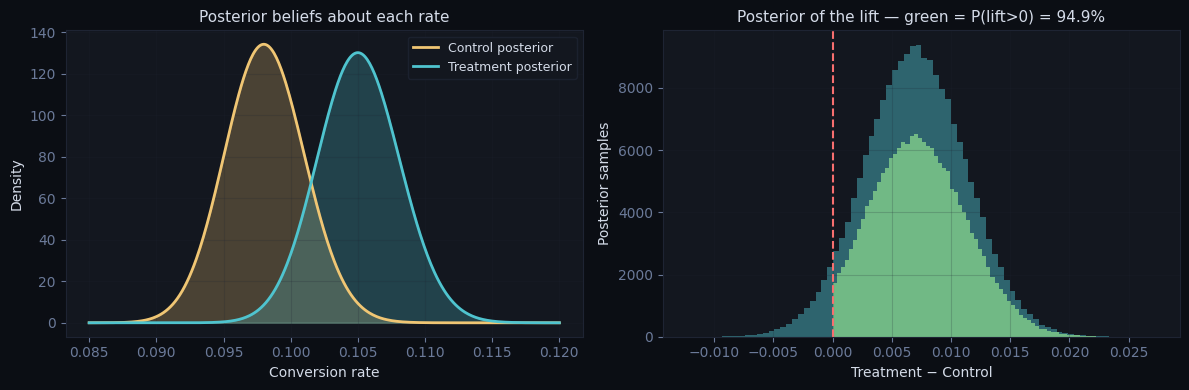

In [11]:
from scipy.stats import beta as beta_dist

# Same data as §2: ctrl 980/10,000, trt 1,050/10,000 — uniform Beta(1,1) prior
post_c = beta_dist(1 + 980,   1 + 10_000 - 980)
post_t = beta_dist(1 + 1_050, 1 + 10_000 - 1_050)

rng = np.random.default_rng(0)
s_c, s_t = post_c.rvs(200_000, random_state=1), post_t.rvs(200_000, random_state=2)
lift = s_t - s_c

p_better      = (lift > 0).mean()
exp_loss_ship = np.maximum(s_c - s_t, 0).mean()    # loss if we ship trt and it's worse
exp_loss_keep = np.maximum(s_t - s_c, 0).mean()    # loss if we keep ctrl and trt was better

print(f"P(treatment > control):        {p_better:.1%}")
print(f"Expected loss if SHIP:         {exp_loss_ship:.5f}  ({exp_loss_ship:.3%} conversion)")
print(f"Expected loss if DON'T ship:   {exp_loss_keep:.5f}")
print(f"Decision rule: ship when expected loss < ε (e.g. ε = 0.0001) → "
      f"{'SHIP' if exp_loss_ship < 1e-4 else 'keep collecting data'}")

fig, axes = dark_fig(1, 2)
xs = np.linspace(0.085, 0.12, 400)
axes[0].plot(xs, post_c.pdf(xs), color=AMBER, lw=2, label='Control posterior')
axes[0].fill_between(xs, post_c.pdf(xs), alpha=0.25, color=AMBER)
axes[0].plot(xs, post_t.pdf(xs), color=CYAN, lw=2, label='Treatment posterior')
axes[0].fill_between(xs, post_t.pdf(xs), alpha=0.25, color=CYAN)
style_labels(axes[0], 'Conversion rate', 'Density', 'Posterior beliefs about each rate')
dark_legend(axes[0])

axes[1].hist(lift, bins=80, color=CYAN, alpha=0.45)
axes[1].hist(lift[lift > 0], bins=80, color=GREEN, alpha=0.85)
axes[1].axvline(0, color=RED, lw=1.5, ls='--')
style_labels(axes[1], 'Treatment − Control', 'Posterior samples',
             f'Posterior of the lift — green = P(lift>0) = {p_better:.1%}')
plt.tight_layout(); plt.show()

### Frequentist vs Bayesian — the comparison interviewers want

| | Frequentist | Bayesian |
| :--- | :--- | :--- |
| Output | p-value, CI | Full posterior: P(better), expected loss, credible interval |
| Guarantees | α control over repeated experiments | Calibrated *if the prior is honest* |
| Peeking | Breaks fixed-horizon tests (§4.2) | Expected-loss stopping is fairly robust, but **not** immune — optional stopping still biases posteriors with flat priors |
| Sample size | Required up front | Can stop on expected loss, usually still plan one |
| Communication | Routinely misread by stakeholders | "93% chance treatment is better" — what people wanted all along |
| Cost | — | Must choose & defend a prior |

Honest interview answer: *"Same data, usually the same decision. Bayesian buys interpretability and a principled loss-based stopping rule; frequentist buys hard error-rate guarantees and no prior to argue about. I'd match whatever the org's platform implements consistently."*

### Bridge to multi-armed bandits

A/B testing and bandits answer different questions:

```
A/B test   Fixed allocation. Goal: precise INFERENCE of the effect (then a one-time decision).
Bandit     Adaptive allocation (e.g. Thompson sampling: sample each arm's posterior,
           play the argmax). Goal: minimize REGRET — earn while you learn.

Use a bandit when:  many arms, short-lived decisions (headlines, promos), opportunity
                    cost of showing losers is high, no need for a precise effect size.
Use an A/B when:    you need the effect size & CI (ship decisions, strategy),
                    guardrails matter, effects may be delayed or novelty-driven.
```

Caveat worth stating: adaptive allocation makes naive post-hoc effect estimates biased — if asked to "measure the effect from bandit data," that needs special handling.

In [12]:
# ── Thompson sampling in 15 lines: traffic migrates to the better arm ────────
np.random.seed(4)
true_p = [0.100, 0.108]                  # arm 1 truly better
a = np.ones(2); b = np.ones(2)           # Beta(1,1) priors
pulls = np.zeros(2, int)

for t in range(30_000):
    arm = int(np.argmax(np.random.beta(a, b)))      # sample posteriors, play argmax
    reward = np.random.rand() < true_p[arm]
    a[arm] += reward; b[arm] += 1 - reward
    pulls[arm] += 1

print(f"Traffic share after 30k users:  arm0 {pulls[0]/pulls.sum():.0%}, "
      f"arm1 {pulls[1]/pulls.sum():.0%}  (arm1 is truly better)")
print(f"Posterior means: {a/(a+b)}")
print("→ regret minimized, but arm0's estimate is based on little, early-stopped data —")
print("  don't read bandit traffic shares as an unbiased effect estimate.")

Traffic share after 30k users:  arm0 8%, arm1 92%  (arm1 is truly better)
Posterior means: [0.0956671  0.11155278]
→ regret minimized, but arm0's estimate is based on little, early-stopped data —
  don't read bandit traffic shares as an unbiased effect estimate.


---
## §6 — Common Pitfalls & Diagnostics

These are the interview favorites — the scenarios where a naive analysis gives the wrong answer.

### Pitfall 1: Peeking
Covered in depth in §4.2 — each peek is an additional test; 5 peeks at α=0.05 → ~19% real FPR. Fix: pre-specified horizon, or sequential/always-valid methods (§4.3).

### Pitfall 2: Novelty / Primacy Effect

**Novelty:** users engage *because it's new* — effect spikes in week 1, decays toward zero. **Primacy:** users struggle with change — a genuinely better feature looks worse early. Detection: plot the **effect by week** (below). Fix: run multiple weeks; weight weeks 2–4 in the decision; for strong novelty suspicion, look at new-user cohorts (they have no "old" to compare against).

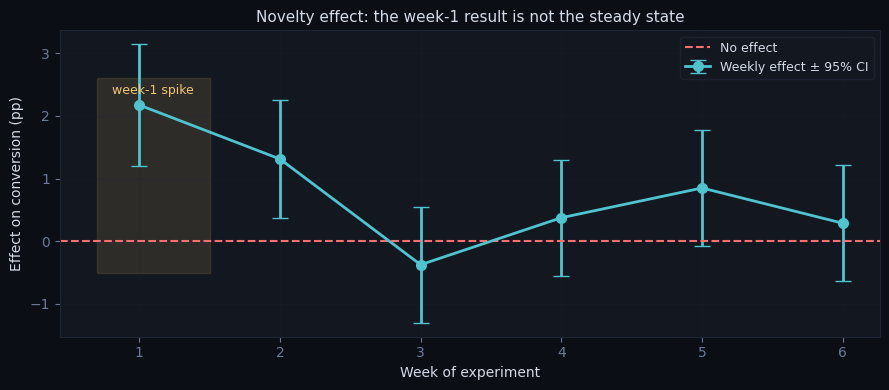

If the launch decision had used week 1 only: +2.0pp. Steady state: ~0.1pp.


In [13]:
# ── The novelty-effect plot: weekly effect estimates with CIs ────────────────
np.random.seed(9)
weeks = np.arange(1, 7)
true_weekly = np.array([2.0, 1.2, 0.55, 0.25, 0.10, 0.05])     # pp, decaying
n_week = 8_000

est, half = [], []
for w, eff in zip(weeks, true_weekly):
    c = np.random.binomial(1, 0.10, n_week)
    t = np.random.binomial(1, 0.10 + eff/100, n_week)
    d = t.mean() - c.mean()
    se = np.sqrt(c.mean()*(1-c.mean())/n_week + t.mean()*(1-t.mean())/n_week)
    est.append(d * 100); half.append(1.96 * se * 100)

fig, ax = dark_fig(figsize=(9, 4))
ax.errorbar(weeks, est, yerr=half, fmt='o-', color=CYAN, lw=2,
            capsize=6, markersize=7, label='Weekly effect ± 95% CI')
ax.axhline(0, color=RED, ls='--', lw=1.5, label='No effect')
ax.fill_between([0.7, 1.5], -0.5, 2.6, color=AMBER, alpha=0.12)
ax.text(1.1, 2.35, 'week-1 spike', color=AMBER, ha='center', fontsize=9)
style_labels(ax, 'Week of experiment', 'Effect on conversion (pp)',
             'Novelty effect: the week-1 result is not the steady state')
dark_legend(ax)
plt.tight_layout(); plt.show()
print("If the launch decision had used week 1 only: +2.0pp. Steady state: ~0.1pp.")

### Pitfall 3: Network Effects / Spillover
Treated users affect control users (shared content, marketplace supply) — a SUTVA violation (Design §0). ATE is under- or overestimated. Fix: cluster or switchback randomization (Design §3, Beyond_AB).

### Pitfall 4: Simpson's Paradox in Segment Analysis
A trend appears overall but reverses within every subgroup — because subgroup *composition* differs between arms (often an SRM symptom at the segment level).

Overall:
group
control      9.65%
treatment    8.62%
Name: rate, dtype: str

Within platform:
group      platform
control    Android       5.1%
           iOS          14.2%
treatment  Android       5.8%
           iOS         11.45%
Name: rate, dtype: str


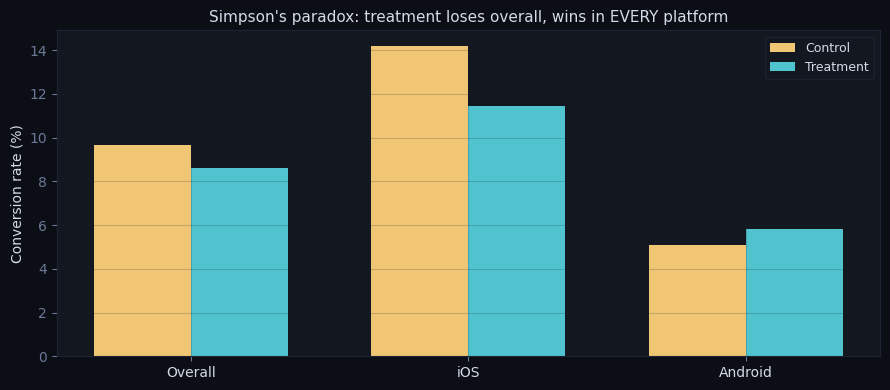

Cause: arms have different platform mixes. Check composition before reading segments.


In [14]:
data = pd.DataFrame({
    'group':    ['control']*4 + ['treatment']*4,
    'platform': ['iOS','iOS','Android','Android'] * 2,
    'users':    [8000, 2000, 1000, 9000,
                 1000, 9000, 8000, 2000],
    'converted':[1200,  220,   60,  450,
                  155,  990,  480,  100]
})
# NOTE: rows are (users, converted) pairs per group×platform from logging
agg = data.groupby(['group','platform']).sum(numeric_only=True)
agg['rate'] = agg.converted / agg.users

overall = data.groupby('group').sum(numeric_only=True)
overall['rate'] = overall.converted / overall.users
print("Overall:\n", (overall['rate']*100).round(2).astype(str) + '%', sep='')
print("\nWithin platform:\n", (agg['rate']*100).round(2).astype(str) + '%', sep='')

fig, ax = dark_fig(figsize=(9, 4))
x = np.arange(3); w = 0.35
rates_c = [overall.loc['control','rate'],  agg.loc[('control','iOS'),'rate'],
           agg.loc[('control','Android'),'rate']]
rates_t = [overall.loc['treatment','rate'], agg.loc[('treatment','iOS'),'rate'],
           agg.loc[('treatment','Android'),'rate']]
ax.bar(x - w/2, np.array(rates_c)*100, w, color=AMBER, label='Control')
ax.bar(x + w/2, np.array(rates_t)*100, w, color=CYAN,  label='Treatment')
ax.set_xticks(x); ax.set_xticklabels(['Overall', 'iOS', 'Android'], color=TXT)
style_labels(ax, ylabel='Conversion rate (%)',
             title="Simpson's paradox: treatment loses overall, wins in EVERY platform")
dark_legend(ax)
plt.tight_layout(); plt.show()
print("Cause: arms have different platform mixes. Check composition before reading segments.")

### Pitfall 5: Day-of-Week Bias
Launching Monday and stopping Thursday captures a biased day mix. Fix: full weeks only; exclude a partial first week.

### Pitfall 6: Survivorship Bias
Comparing average order value *among purchasers only*: if treatment converts marginal buyers (lower AOV), filtering non-buyers makes a good feature look bad. Fix: analyze on the full eligible population (and treat post-treatment filters as red flags generally — same logic as triggered-only analysis, Design §3).

### Pitfall 7: Post-hoc ("observed") power
*"The result wasn't significant — let me compute the power we had, using the observed effect."* Observed power is a **deterministic function of the p-value** — it adds zero information, and p ≈ 0.05 always maps to power ≈ 50%. The right move: assess the **CI width** against the MDE you cared about.

In [15]:
# Observed power is just p re-expressed
print("two-sided p   'observed power'")
for p in [0.01, 0.05, 0.10, 0.31, 0.60]:
    z = stats.norm.ppf(1 - p/2)
    obs_power = 1 - stats.norm.cdf(1.96 - z) + stats.norm.cdf(-1.96 - z)
    print(f"   {p:.2f}    →     {obs_power:.0%}")
print("\np=0.05 → exactly 50% 'power', always. Report the CI vs the MDE instead:")
print("  'CI [−0.2pp, +0.6pp] rules out effects above 0.6pp — our MDE was 0.5pp,")
print("   so the experiment was adequately powered and the effect, if any, is small.'")

two-sided p   'observed power'
   0.01    →     73%
   0.05    →     50%
   0.10    →     38%
   0.31    →     17%
   0.60    →     8%

p=0.05 → exactly 50% 'power', always. Report the CI vs the MDE instead:
  'CI [−0.2pp, +0.6pp] rules out effects above 0.6pp — our MDE was 0.5pp,
   so the experiment was adequately powered and the effect, if any, is small.'


### Quick Diagnostic Checklist

| Symptom | Likely cause | Investigation |
| :--- | :--- | :--- |
| Effect is huge in week 1, decays | Novelty effect | Plot effect by week |
| Effect looks worse despite better UX | Primacy effect | Run longer, check week 3+ |
| SRM detected | Logging bug, bot filtering | Pause experiment, audit pipeline |
| Segment results contradict overall | Simpson's paradox | Check group composition by segment |
| Control improves during treatment period | Spillover | Consider cluster randomization |
| Significant at day 7, not at day 14 | Peeking / noise | Trust the pre-specified endpoint only |
| Result too good to be true (Twyman's law) | Logging bug, SRM, unit mismatch | Re-verify pipeline before celebrating |
| "Compute the power we had" requests | Post-hoc power fallacy | Report CI width vs MDE instead |

---
## §7 — Decisions & Communication

The analysis is only useful if it drives a decision. Structure your communication around the decision, not the statistics.

### The launch decision matrix

| Primary metric | Guardrails | Cost/risk of shipping | Decision |
| :--- | :--- | :--- | :--- |
| Significant + | Clean | Any | **Ship** |
| Significant + | Degraded | Any | **No-ship** — fix, re-test |
| Marginal (p ≈ 0.05–0.15), CI mostly + | Clean | Low / reversible | **Ship or extend** — judgment call, say so explicitly |
| Marginal | Clean | High / irreversible | **Extend** the experiment (pre-register the extension) or no-ship |
| Not significant, CI tight around 0 | Clean | Any | **No-ship** — true effect, if any, is below MDE |
| Not significant, CI wide | Clean | — | **Underpowered** — rerun bigger or drop; don't conclude "no effect" |
| Significant − | — | — | **No-ship**; investigate, salvage learnings |

**The "p = 0.06" answer:** don't recite the 0.05 ritual. Say: *"0.05 is a convention, not physics. I'd look at the CI against our MDE, the guardrails, and the cost of being wrong in each direction. For a cheap, reversible change with a CI mostly above zero I'd lean ship (or extend with a pre-registered second look); for an expensive irreversible one, I'd extend or decline. What I would not do is quietly keep collecting data until it crosses 0.05 — that's peeking."*

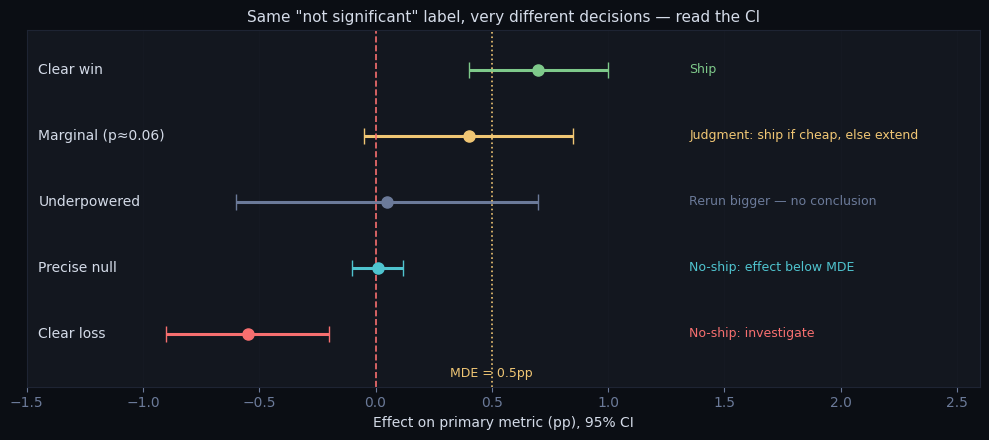

In [16]:
# ── The CI-vs-decision chart: five archetypes ────────────────────────────────
cases = [
    ('Clear win',            0.70, 0.30, GREEN,  'Ship'),
    ('Marginal (p≈0.06)',    0.40, 0.45, AMBER,  'Judgment: ship if cheap, else extend'),
    ('Underpowered',         0.05, 0.65, MUT,    'Rerun bigger — no conclusion'),
    ('Precise null',         0.01, 0.11, CYAN,   'No-ship: effect below MDE'),
    ('Clear loss',          -0.55, 0.35, RED,    'No-ship: investigate'),
]
fig, ax = dark_fig(figsize=(10, 4.5))
for i, (name, mid, half, c, decision) in enumerate(cases):
    y = len(cases) - i
    ax.errorbar([mid], [y], xerr=[[half], [half]], fmt='o', color=c,
                capsize=6, markersize=8, lw=2.2)
    ax.text(-1.45, y, name, color=TXT, va='center', fontsize=10)
    ax.text(1.35, y, decision, color=c, va='center', fontsize=9)
ax.axvline(0, color=RED, ls='--', lw=1.2)
ax.axvline(0.5, color=AMBER, ls=':', lw=1.2)
ax.text(0.5, 0.35, 'MDE = 0.5pp', color=AMBER, ha='center', fontsize=9)
ax.set_xlim(-1.5, 2.6); ax.set_ylim(0.2, len(cases) + 0.6); ax.set_yticks([])
style_labels(ax, 'Effect on primary metric (pp), 95% CI',
             title='Same "not significant" label, very different decisions — read the CI')
plt.tight_layout(); plt.show()

### Non-inferiority: shipping for non-metric reasons

Sometimes you ship for cost, simplification, or compliance and only need "**not worse than** a margin δ". Flip the hypothesis: H₀ becomes "treatment is worse by ≥ δ"; reject if the **one-sided lower CI bound > −δ**. Note that "not significant" is *never* evidence of non-inferiority — an underpowered test passes nothing.

In [17]:
def non_inferiority(ctrl, trt, margin, alpha=0.05):
    """One-sided test: is treatment NOT worse than control by more than `margin`?"""
    d  = trt.mean() - ctrl.mean()
    se = np.sqrt(ctrl.var(ddof=1)/len(ctrl) + trt.var(ddof=1)/len(trt))
    lower = d - stats.norm.ppf(1 - alpha) * se          # one-sided lower bound
    ok = lower > -margin
    print(f"Diff = {d:+.4f}, one-sided {1-alpha:.0%} lower bound = {lower:+.4f}, "
          f"margin = −{margin}")
    print("→ NON-INFERIOR (ship the cheaper version)" if ok
          else "→ cannot rule out being worse than the margin — do not ship")
    return ok

# New infra serves the same conversion rate, much cheaper. Margin: 0.3pp.
np.random.seed(2)
old = np.random.binomial(1, 0.100, 60_000).astype(float)
new = np.random.binomial(1, 0.0995, 60_000).astype(float)
non_inferiority(old, new, margin=0.003)

Diff = -0.0016, one-sided 95% lower bound = -0.0045, margin = −0.003
→ cannot rule out being worse than the margin — do not ship


np.False_

### Long-term effects & holdouts

Short experiments overstate some wins (novelty, §6) and miss slow harms (ad-load fatigue, trust erosion) and slow wins (habit formation). Standard tools:

- **Long-term holdout:** keep 1–5% of users on the old experience for months after shipping; compare quarterly. Measures the *cumulative* effect of the launch (or of all launches, if it's a global holdout).
- **Effect-over-time read:** the weekly-effect plot (§6) before extrapolating any result to an annualized impact.
- Caveats to state: holdouts decay (users hear about features), have ethics/cost limits, and a global holdout measures the *bundle* of launches, not your one feature.

### The Recommendation Structure

```
1. Bottom line up front     Ship / No-ship / Iterate — one sentence.

2. What moved               Primary metric: direction, magnitude, confidence interval.
                            "Conversion rate increased by 0.7pp (7% relative lift),
                             95% CI [0.3pp, 1.1pp], p=0.001."

3. Business impact          Translate to revenue / users / business terms.
                            "At current traffic, this is ~$2M incremental annual
                             revenue — assuming the week-2+ effect holds (novelty
                             checked, §6)."

4. Guardrails               Confirm no guardrail degraded.
                            "Latency, unsubscribe rate, and crash rate all within bounds."

5. Caveats                  Novelty effect? Segment heterogeneity? Power limitations?

6. Recommendation           Ship / no-ship / run a follow-up experiment.
```

### Framing for Common Scenarios

**Scenario 1: Result is not significant**
> *"We did not detect a statistically significant effect (p=0.31). This does not mean the feature has no effect — the experiment may be underpowered. The 95% CI is [−0.2pp, +0.6pp], which is consistent with both a small positive effect and no effect. Recommendation: if the feature is low-cost, consider running a longer experiment; if high-cost, do not ship."*

**Scenario 2: Primary metric positive, guardrail degraded**
> *"Conversion rate increased by 0.7pp (significant), but page load time increased by 120ms, exceeding our 50ms guardrail threshold. We should not ship in its current form. The engineering team should optimize the implementation before re-testing."*

**Scenario 3: Heterogeneous treatment effects**
> *"The overall ATE is +0.5pp. However, the effect is concentrated in iOS users (+1.2pp) and is near zero for Android users (+0.1pp, not significant). We may want to consider platform-specific rollout or investigate why the feature underperforms on Android."*

### What NOT to Say

| Avoid | Say instead |
| :--- | :--- |
| "p=0.04, so the result is significant" | Report the effect size and CI alongside p-value |
| "The experiment proved the feature works" | "The experiment provides evidence that..." |
| "No effect was found" (when underpowered) | "We did not detect an effect; the experiment may be underpowered" |
| "The segment analysis shows..." (without correction) | "Exploratory segment analysis suggests... requires follow-up" |
| "We had 50% observed power" | Compare the CI width against the pre-registered MDE |

---
## Decision Guide

```
Running the analysis?
└── Always: SRM → balance → data quality → primary → guardrails → segments
            → recommend                                                          (§1)

Choosing the statistical test?
├── Continuous metric (revenue, time)       → two-sample t-test                  (§2)
├── Proportion (conversion, CTR per user)   → z-test for proportions             (§2)
├── Skewed / heavy-tailed                   → Winsorize (state estimand change),
│                                             Mann-Whitney, or bootstrap         (§2)
├── Ratio metric, randomized by user        → delta method or bootstrap users    (§2)
└── Always report: ATE + 95% CI + effect size, not just p-value                  (§2)

Want faster results or smaller sample?
├── CUPED — pre-experiment covariate, pooled θ                                   (§3)
├── No pre-period data → post-stratification / regression adjustment             (§3)
└── ML prediction as covariate → CUPAC                                           (§3)

Testing multiple things — or looking more than once?
├── One pre-registered primary metric       → no correction needed               (§4)
├── Multiple secondary metrics / segments   → Benjamini-Hochberg FDR             (§4)
├── Safety / irreversible decisions         → Bonferroni                         (§4)
├── Need interim looks                      → O'Brien-Fleming alpha spending     (§4)
└── Dashboard watched daily regardless      → always-valid inference (mSPRT)     (§4)

Asked "why not Bayesian?"
└── Same decision usually; posterior P(better) + expected-loss stopping vs hard
    α guarantees; bandits when regret > inference                                (§5)

Results look wrong?
├── Effect huge then decays                 → novelty → plot effect by week      (§6)
├── Segment contradicts overall             → Simpson's → check composition      (§6)
├── SRM detected                            → stop, audit pipeline               (§6)
├── Control improves during test            → spillover → cluster randomization  (§6)
├── Significant early, not later            → peeking artifact → trust endpoint  (§6)
└── Asked for "the power we had"            → post-hoc power fallacy → CI vs MDE (§6)

Presenting results?
├── Decision matrix first, then: bottom line → what moved → business impact
│   → guardrails → caveats → recommendation                                      (§7)
├── Shipping for cost, need "not worse"     → non-inferiority margin test        (§7)
└── Long-run impact claim                   → holdout / effect-over-time         (§7)
```